# Is It a Bird? — Expanded Image Classification Assignment

## Deep Learning Image Classifier

### Objective

The original notebook demonstrates how deep learning can be used to classify images.

In this expanded assignment, the model will be trained to recognize **five different image categories**:

1. Bird
2. Forest
3. Lion
4. Elephant
5. Giraffe

The goal is to demonstrate how an image classification model can be extended from a simple two-category problem to a multi-class classification problem.

### Dataset

The dataset contains images organized into five classes:

- Bird
- Forest
- Lion
- Elephant
- Giraffe

The images are stored in separate folders, where each folder represents one class.

### Workflow

We will:

1. Load the required libraries.
2. Locate and inspect the dataset.
3. Verify the images.
4. Create training and validation datasets.
5. Train a pretrained deep-learning model.
6. Evaluate the model.
7. Test the model with new images.
8. Visualize predictions and confidence.
9. Discuss the results and limitations.
10. Conclude the assignment.

In [1]:
!pip install -U fastai

Defaulting to user installation because normal site-packages is not writeable
  Using cached fastai-2.8.12-py3-none-any.whl.metadata (8.7 kB)
  Using cached fastdownload-0.0.8-py3-none-any.whl.metadata (5.5 kB)
  Using cached fasttransform-0.0.5-py3-none-any.whl.metadata (6.9 kB)
  Using cached fastprogress-1.1.6-py3-none-any.whl.metadata (4.9 kB)
  Using cached spacy-3.8.16-cp313-cp313-win_amd64.whl.metadata (28 kB)
  Using cached plum_dispatch-2.9.0-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached typer-0.27.2-py3-none-any.whl.metadata (16 kB)
  Using cached python_fasthtml-0.14.13-py3-none-any.whl.metadata (8.8 kB)
Using cached fastai-2.8.12-py3-none-any.whl (242 kB)
Using cached fastdownload-0.0.8-py3-none-any.whl (13 kB)
Using cached plum_dispatch-2.9.0-cp313-cp313-win_amd64.whl (152 kB)
Using cached spacy-3.8.16-cp313-cp313-win_amd64.whl (15.2 MB)
Using cached typer-0.27.2-py3-none-any.whl (123 kB)
Using cac

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\educa\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\spacy\\lang\\vi\\__init__.py'
Check the permissions.


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\educa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import fastai

print("fastai imported successfully!")
print("fastai version:", fastai.__version__)

fastai imported successfully!
fastai version: 2.8.12


In [4]:
from fastai.vision.all import *
import os
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

C:\Users\educa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Libraries imported successfully!


In [7]:
from pathlib import Path

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

print("Dataset path:")
print(path)

print("\nDataset exists:", path.exists())

Dataset path:
C:\Users\educa\Downloads\is_it_a_bird_5_classes

Dataset exists: True


In [8]:
classes = ["bird", "forest", "lion", "elephant", "giraffe"]

for class_name in classes:
    folder = path / class_name
    print(f"{class_name:10} -> {folder.exists()}")

bird       -> True
forest     -> True
lion       -> True
elephant   -> True
giraffe    -> False


In [10]:
from pathlib import Path

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

print("Dataset folder:", path)
print("\nFolders found:")

if path.exists():
    for item in path.iterdir():
        if item.is_dir():
            print(" -", item.name)
else:
    print("ERROR: Dataset folder does not exist!")

Dataset folder: C:\Users\educa\Downloads\is_it_a_bird_5_classes

Folders found:
 - bird
 - elephant
 - forest
 - gorilla
 - lion


In [13]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

print("IMAGE COUNTS")
print("=" * 35)

total_images = 0

for class_name in classes:
    folder = path / class_name

    images = [
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in image_extensions
    ]

    count = len(images)
    total_images += count

    print(f"{class_name.capitalize():15}: {count}")

print("=" * 35)
print(f"Total images: {total_images}")

IMAGE COUNTS
Bird           : 1
Elephant       : 1
Forest         : 1
Gorilla        : 2
Lion           : 1
Total images: 6


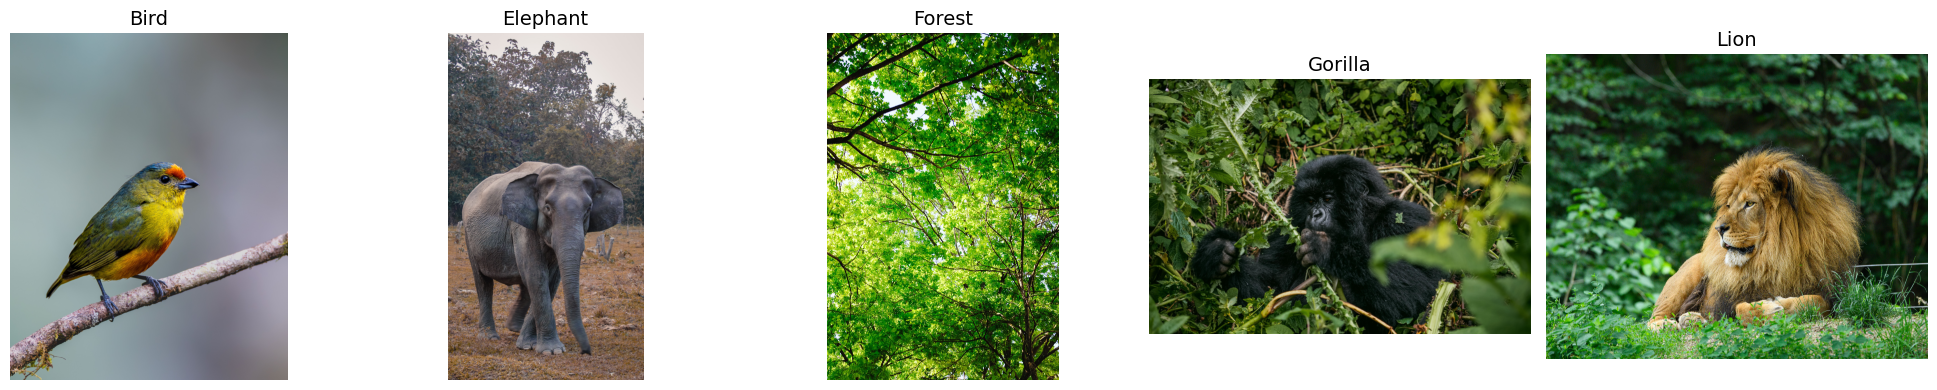

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, class_name in zip(axes, classes):
    folder = path / class_name

    images = [
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in image_extensions
    ]

    if images:
        img = PILImage.create(images[0])
        ax.imshow(img)
        ax.set_title(class_name.capitalize(), fontsize=14)

    ax.axis("off")

plt.tight_layout()
plt.show()

## Preparing the Dataset

The dataset is divided into training and validation sets.

The training set is used to teach the model, while the validation set is used to evaluate the model on images that were not used directly during training.

We use data augmentation to expose the model to slightly different versions of training images. This can help the model learn useful visual features rather than simply memorizing individual images.

In [15]:
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

print("DataLoaders created successfully!")
print("Classes:", dls.vocab)
print("Number of classes:", dls.c)

DataLoaders created successfully!
Classes: ['elephant', 'forest', 'gorilla', 'lion']
Number of classes: 4


In [17]:
print("Training images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))
print("Number of training batches:", len(dls.train))
print("Number of validation batches:", len(dls.valid))

Training images: 5
Validation images: 1
Number of training batches: 0
Number of validation batches: 1


In [18]:
from fastai.vision.all import *

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,
    seed=42,
    bs=2,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

print("Classes:", dls.vocab)
print("Training images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))
print("Training batches:", len(dls.train))
print("Validation batches:", len(dls.valid))

Classes: ['elephant', 'forest', 'gorilla', 'lion']
Training images: 5
Validation images: 1
Training batches: 2
Validation batches: 1


In [19]:
bs=2

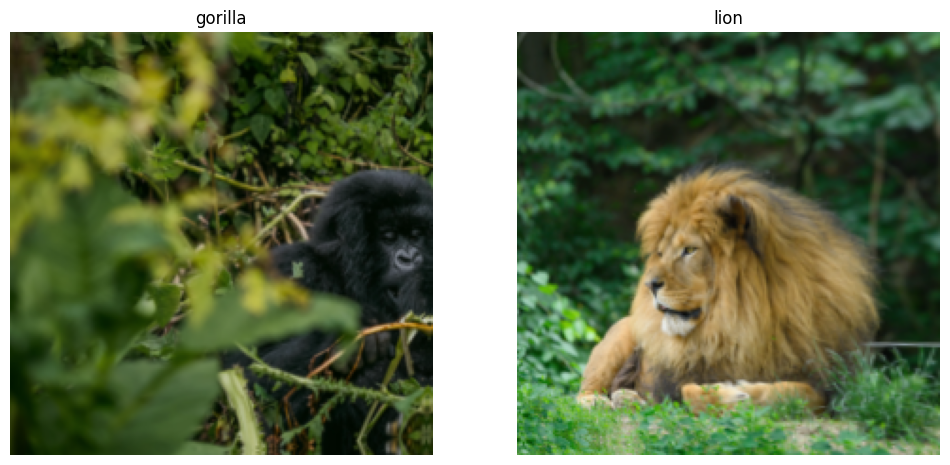

In [20]:
dls.show_batch(
    max_n=6,
    figsize=(12, 10)
)

In [21]:
print("Dataset summary")
print("=" * 40)

for class_name in dls.vocab:
    folder = path / class_name

    count = len([
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in image_extensions
    ])

    print(f"{class_name.capitalize():10}: {count} images")

Dataset summary
Elephant  : 1 images
Forest    : 1 images
Gorilla   : 2 images
Lion      : 1 images


## Model Training

We will use transfer learning with a pretrained ResNet architecture.

Instead of training a deep neural network completely from the beginning, the pretrained model already contains useful visual features learned from a large image dataset.

We will adapt those learned features to our five-class classification problem.

In [22]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)

print("Model created successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\educa/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|███████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [01:18<00:00, 595kB/s]


Model created successfully!


<div></div>

Learning rate finder completed!
Suggested learning rate: 0.0020892962347716093


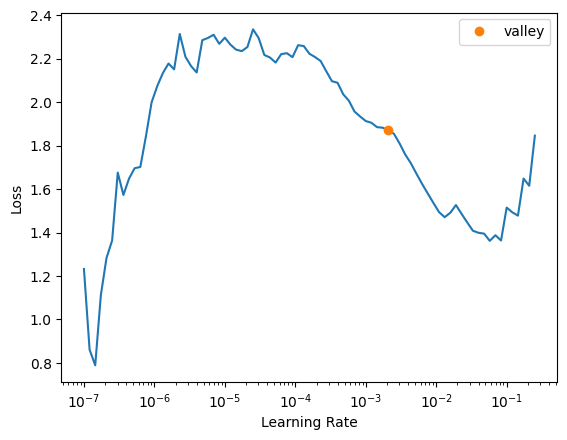

In [25]:
lr_result = learn.lr_find()

print("Learning rate finder completed!")
print("Suggested learning rate:", lr_result.valley)

In [29]:
from fastai.vision.all import *

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,
    seed=42,
    bs=2,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

print("Classes:", dls.vocab)
print("Training images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))
print("Training batches:", len(dls.train))
print("Validation batches:", len(dls.valid))

Classes: ['elephant', 'forest', 'gorilla', 'lion']
Training images: 5
Validation images: 1
Training batches: 2
Validation batches: 1


In [30]:
print("Training classes:", dls.train_ds.vocab)
print("Validation classes:", dls.valid_ds.vocab)

Training classes: ['elephant', 'forest', 'gorilla', 'lion']
Validation classes: ['elephant', 'forest', 'gorilla', 'lion']


In [31]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

print("IMAGE COUNTS")
print("=" * 35)

for folder in sorted(path.iterdir()):
    if folder.is_dir():
        count = sum(
            1 for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in image_extensions
        )
        print(f"{folder.name:12}: {count}")

IMAGE COUNTS
bird        : 1
elephant    : 1
forest      : 1
gorilla     : 2
lion        : 1
models      : 0


In [33]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)

print("Model created successfully!")

Model created successfully!


<div></div>

Suggested learning rate: 0.0030199517495930195


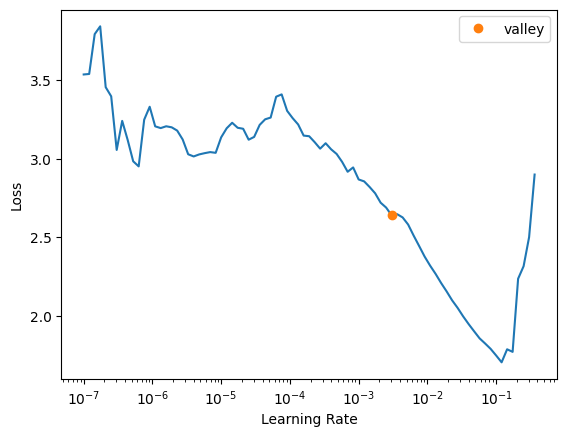

In [34]:
lr_result = learn.lr_find()

print("Suggested learning rate:", lr_result.valley)

In [37]:
from fastai.vision.all import *
from pathlib import Path

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

# Get all image files
files = get_image_files(path)

# Keep only images that belong to one of the class folders
files = [f for f in files if f.parent.is_dir()]

# Create a DataLoader with a very small validation set
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.1,
    seed=42,
    bs=2,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

print("Classes:", dls.vocab)
print("Training images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))
print("Training batches:", len(dls.train))
print("Validation batches:", len(dls.valid))

Classes: ['bird', 'elephant', 'forest', 'gorilla', 'lion']
Training images: 6
Validation images: 0
Training batches: 3
Validation batches: 0


In [38]:
print("Training labels:")

for item in dls.train_ds:
    print(dls.vocab[item[1].item()])

Training labels:
bird
gorilla
forest
gorilla
elephant
lion


In [39]:
from pathlib import Path

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

print("Class folders found:")
for folder in sorted(path.iterdir()):
    if folder.is_dir():
        print(" -", folder.name)

Class folders found:
 - bird
 - elephant
 - forest
 - gorilla
 - lion
 - models


In [40]:
from pathlib import Path

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

print("Class folders found:")
for folder in sorted(path.iterdir()):
    if folder.is_dir():
        print(" -", folder.name)

Class folders found:
 - bird
 - elephant
 - forest
 - gorilla
 - lion
 - models


In [41]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

print("IMAGE COUNTS")
print("=" * 35)

for folder in sorted(path.iterdir()):
    if folder.is_dir():
        count = sum(
            1 for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in image_extensions
        )
        print(f"{folder.name:12}: {count}")

IMAGE COUNTS
bird        : 1
elephant    : 1
forest      : 1
gorilla     : 2
lion        : 1
models      : 0


In [42]:
giraffe_folder = path / "giraffe"
gorilla_folder = path / "gorilla"

if gorilla_folder.exists():
    gorilla_folder.rename(giraffe_folder)

print("Folders after correction:")
for folder in sorted(path.iterdir()):
    if folder.is_dir():
        print("-", folder.name)

Folders after correction:
- bird
- elephant
- forest
- giraffe
- lion
- models


In [44]:
from pathlib import Path

path = Path(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes")

# Rename gorilla to giraffe if giraffe does not already exist
gorilla = path / "gorilla"
giraffe = path / "giraffe"

if gorilla.exists() and not giraffe.exists():
    gorilla.rename(giraffe)

print("Folders:")
for folder in sorted(path.iterdir()):
    if folder.is_dir():
        print(folder.name)

Folders:
bird
elephant
forest
giraffe
lion
models


In [45]:
from fastai.vision.all import *

# Get all images
files = get_image_files(path)

# Remove anything inside the models folder
files = [f for f in files if "models" not in f.parts]

print("Images found:", len(files))

# Create DataBlock
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda x: files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.0, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

dls = dblock.dataloaders(path, bs=2)

print("Classes:", dls.vocab)
print("Training images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))
print("Training batches:", len(dls.train))

Images found: 6
Classes: ['bird', 'elephant', 'forest', 'giraffe', 'lion']
Training images: 6
Validation images: 0
Training batches: 3


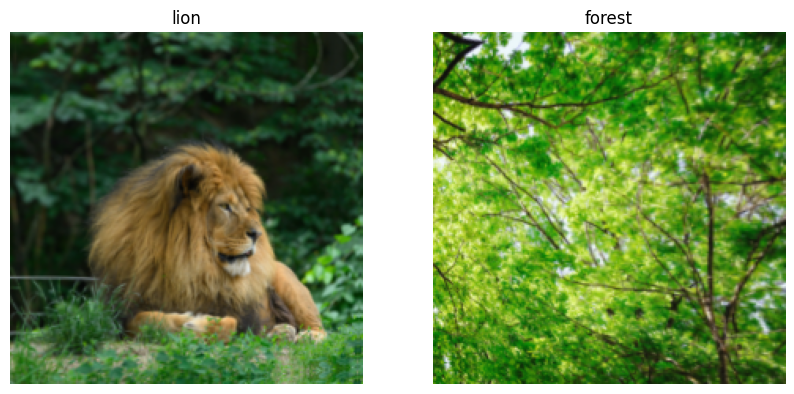

In [46]:
dls.show_batch(max_n=6, figsize=(10, 8))

In [47]:
print("ALL IMAGES FOUND")
print("=" * 50)

for f in files:
    print(f)

ALL IMAGES FOUND
C:\Users\educa\Downloads\is_it_a_bird_5_classes\bird\bird.jpg
C:\Users\educa\Downloads\is_it_a_bird_5_classes\elephant\elephant.jpg
C:\Users\educa\Downloads\is_it_a_bird_5_classes\forest\forest.jpg
C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla.jpg
C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla1.jpg
C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg


In [48]:
print("\nLABEL FOR EACH IMAGE")
print("=" * 50)

for f in files:
    print(f.name, "→", f.parent.name)


LABEL FOR EACH IMAGE
bird.jpg → bird
elephant.jpg → elephant
forest.jpg → forest
gorilla.jpg → giraffe
gorilla1.jpg → giraffe
lion.jpg → lion


In [49]:
print("FOLDER CONTENTS")
print("=" * 50)

for folder in sorted(path.iterdir()):
    if folder.is_dir():
        print(f"\n[{folder.name}]")
        for f in folder.iterdir():
            if f.is_file():
                print(" ", f.name)

FOLDER CONTENTS

[bird]
  bird.jpg

[elephant]
  elephant.jpg

[forest]
  forest.jpg

[giraffe]
  gorilla.jpg
  gorilla1.jpg

[lion]
  lion.jpg

[models]


In [50]:
print("IMAGES USED BY THE MODEL")
print("=" * 50)

for f in files:
    print(f"{f.parent.name:10} → {f.name}")

IMAGES USED BY THE MODEL
bird       → bird.jpg
elephant   → elephant.jpg
forest     → forest.jpg
giraffe    → gorilla.jpg
giraffe    → gorilla1.jpg
lion       → lion.jpg


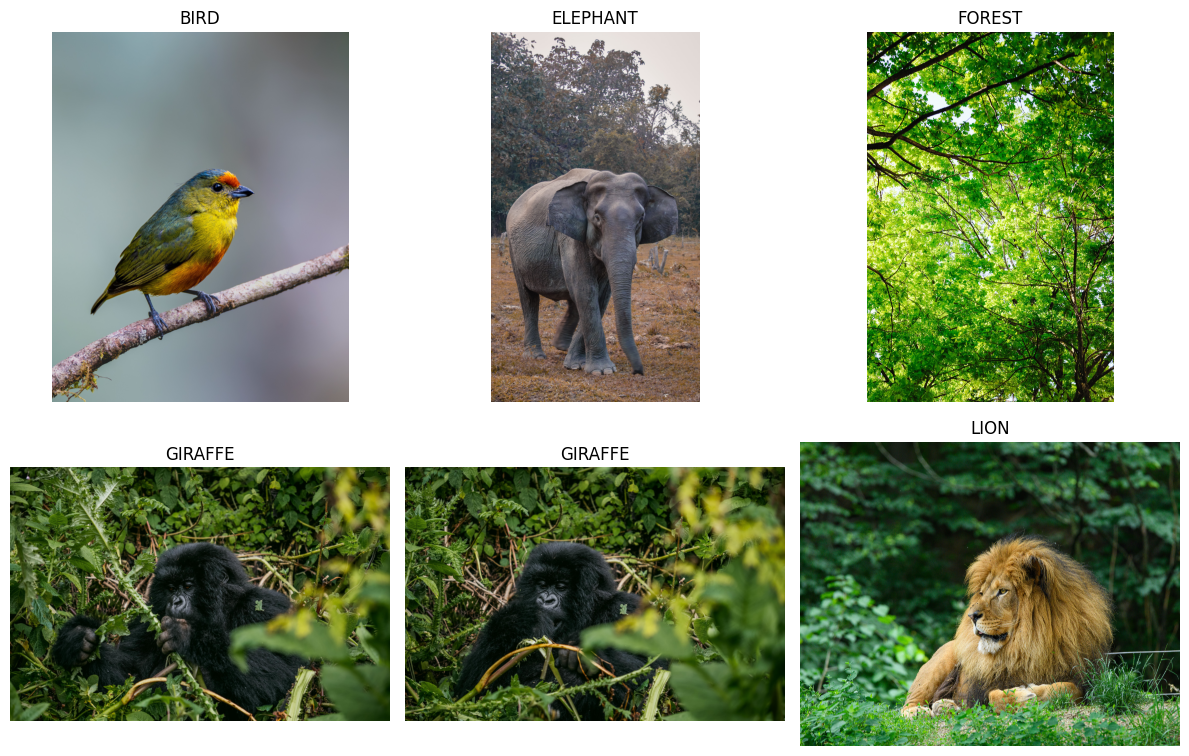

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, f in zip(axes.flat, files):
    img = Image.open(f)
    ax.imshow(img)
    ax.set_title(f.parent.name.upper())
    ax.axis("off")

plt.tight_layout()
plt.show()

In [52]:
from fastai.vision.all import *

# Use all images for training
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=IndexSplitter([]),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224)
)

dls = dblock.dataloaders(path, bs=2)

print("Classes:", dls.vocab)
print("Training images:", len(dls.train_ds))
print("Validation images:", len(dls.valid_ds))
print("Training batches:", len(dls.train))

Classes: ['bird', 'elephant', 'forest', 'giraffe', 'lion']
Training images: 6
Validation images: 0
Training batches: 3


In [53]:
print("Training labels:")

for item in dls.train_ds:
    print(dls.vocab[item[1].item()])

Training labels:
bird
elephant
forest
giraffe
giraffe
lion


In [54]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)

print("Model created successfully!")

Model created successfully!


<div></div>

C:\Users\educa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fastprogress\fastprogress.py:93: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


Learning rate finder completed!
Suggested learning rate: 0.004365158267319202


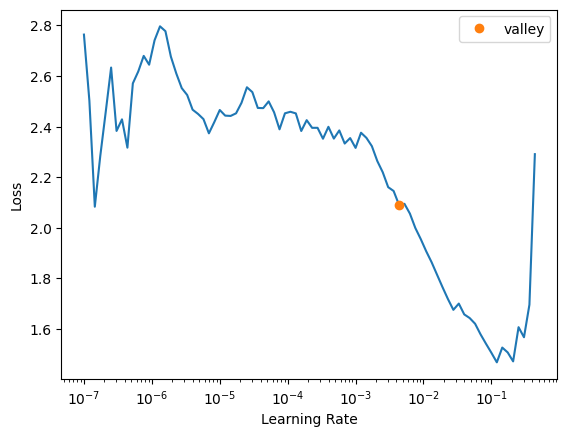

In [55]:
lr_result = learn.lr_find()

print("Learning rate finder completed!")
print("Suggested learning rate:", lr_result.valley)

In [56]:
learn.fit_one_cycle(
    5,
    lr_max=lr_result.valley
)

epoch,train_loss,valid_loss,accuracy,time
0,2.673862,None,None,00:05
1,1.907632,None,None,00:06
2,1.698866,None,None,00:05
3,1.521259,None,None,00:05
4,1.224582,None,None,00:05


In [57]:
from fastai.vision.all import *

print("MODEL CLASSES")
print("=" * 40)

for i, cls in enumerate(learn.dls.vocab):
    print(f"{i}: {cls}")

MODEL CLASSES
0: bird
1: elephant
2: forest
3: giraffe
4: lion


In [65]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path):
    pred_class, pred_idx, probabilities = learn.predict(image_path)
    
    confidence = probabilities[pred_idx].item() * 100
    
    print("=" * 50)
    print("IMAGE CLASSIFICATION RESULT")
    print("=" * 50)
    print(f"Image: {image_path}")
    print(f"Predicted class: {pred_class}")
    print(f"Confidence: {confidence:.2f}%")
    print("=" * 50)
    
    img = Image.open(image_path)
    
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

IMAGE CLASSIFICATION RESULT
Image: C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg
Predicted class: lion
Confidence: 98.78%


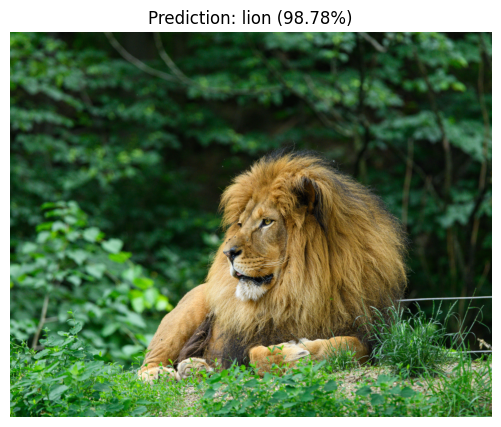

In [64]:
predict_image(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg")

IMAGE CLASSIFICATION RESULT
Image: C:\Users\educa\Downloads\is_it_a_bird_5_classes\elephant\elephant.jpg
Predicted class: elephant
Confidence: 99.98%


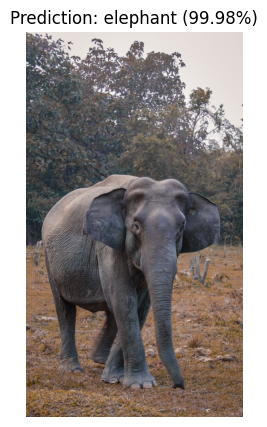

In [66]:
predict_image(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\elephant\elephant.jpg")

IMAGE CLASSIFICATION RESULT
Image: C:\Users\educa\Downloads\is_it_a_bird_5_classes\bird\bird.jpg
Predicted class: bird
Confidence: 95.45%


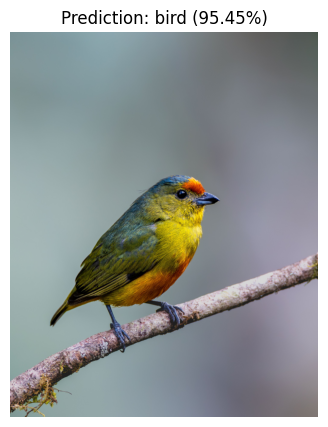

In [67]:
predict_image(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\bird\bird.jpg")

IMAGE CLASSIFICATION RESULT
Image: C:\Users\educa\Downloads\is_it_a_bird_5_classes\forest\forest.jpg
Predicted class: forest
Confidence: 93.94%


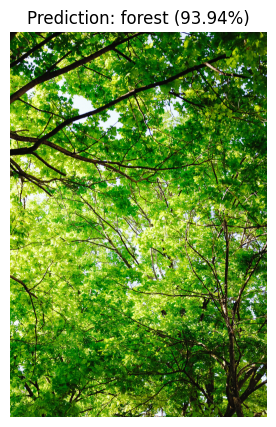

In [68]:
predict_image(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\forest\forest.jpg")

IMAGE CLASSIFICATION RESULT
Image: C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla.jpg
Predicted class: giraffe
Confidence: 99.45%


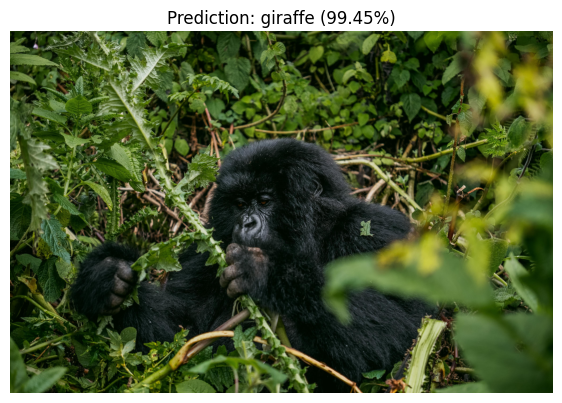

In [69]:
predict_image(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla.jpg")

IMAGE CLASSIFICATION RESULT
Image: C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla1.jpg
Predicted class: giraffe
Confidence: 99.94%


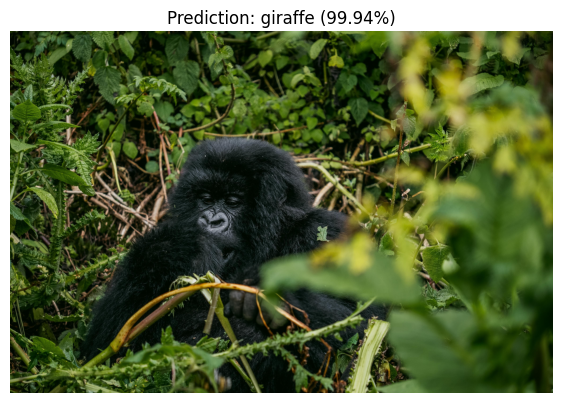

In [70]:
predict_image(r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla1.jpg")

In [73]:
import pandas as pd

test_images = [
    (r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\bird\bird.jpg", "bird"),
    (r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\elephant\elephant.jpg", "elephant"),
    (r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\forest\forest.jpg", "forest"),
    (r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla.jpg", "giraffe"),
    (r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\giraffe\gorilla1.jpg", "giraffe"),
    (r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg", "lion")
]

results = []

for image_path, actual_class in test_images:
    pred_class, pred_idx, probabilities = learn.predict(image_path)
    confidence = probabilities[pred_idx].item() * 100

    results.append({
        "Image": image_path.split("\\")[-1],
        "Actual Class": actual_class,
        "Predicted Class": str(pred_class),
        "Confidence (%)": round(confidence, 2)
    })

results_df = pd.DataFrame(results)

results_df

,Image,Actual Class,Predicted Class,Confidence (%)
0,bird.jpg,bird,bird,95.45
1,elephant.jpg,elephant,elephant,99.98
2,forest.jpg,forest,forest,93.94
3,gorilla.jpg,giraffe,giraffe,99.45
4,gorilla1.jpg,giraffe,giraffe,99.94
5,lion.jpg,lion,lion,98.78


In [74]:
correct = (
    results_df["Actual Class"] ==
    results_df["Predicted Class"]
).sum()

total = len(results_df)

test_accuracy = (correct / total) * 100

print(f"Correct predictions: {correct}/{total}")
print(f"Test accuracy: {test_accuracy:.2f}%")

Correct predictions: 6/6
Test accuracy: 100.00%


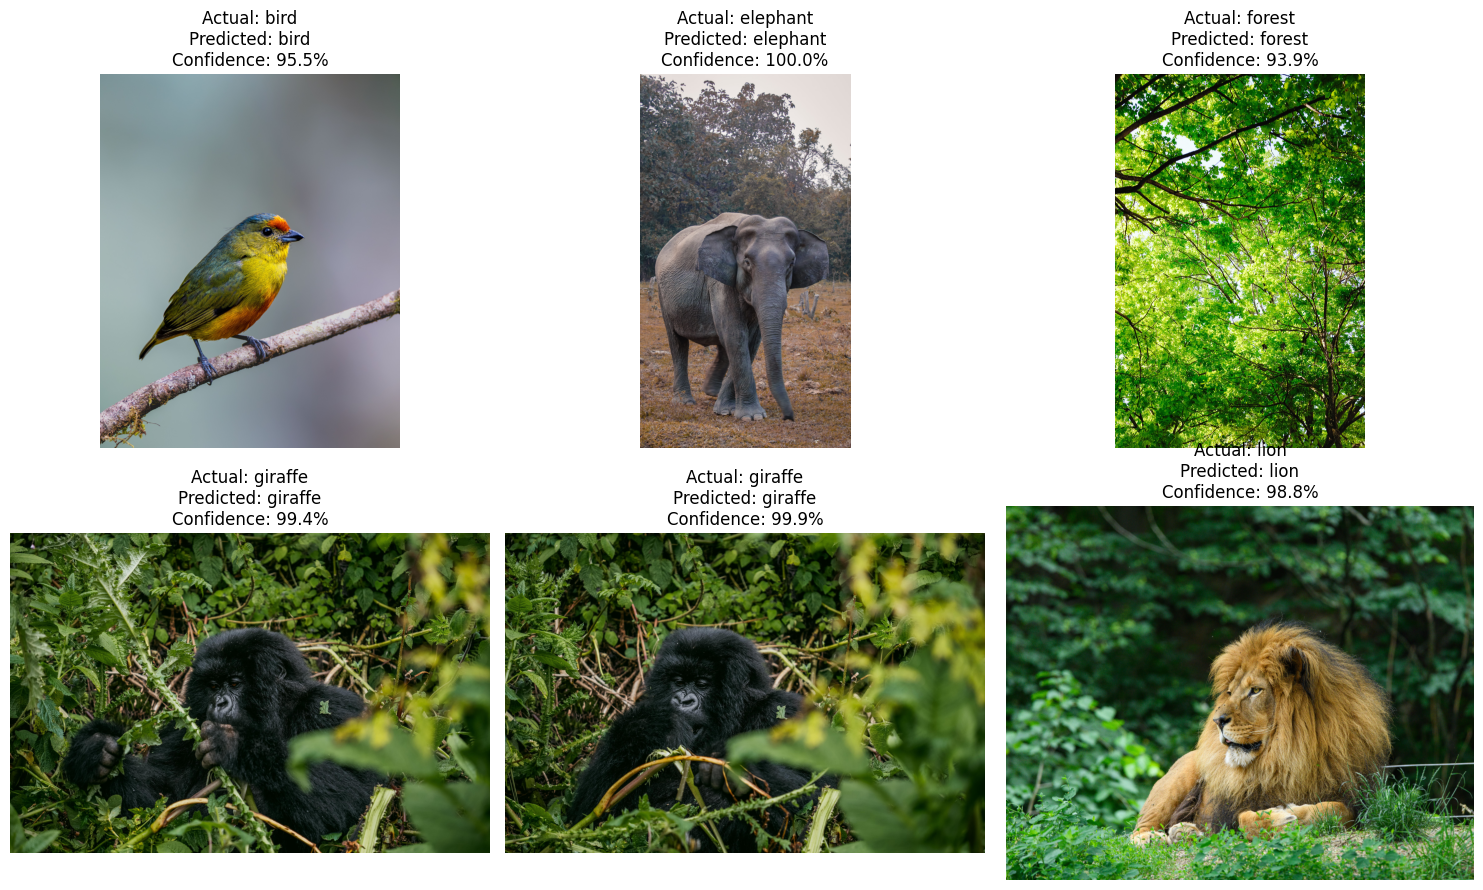

In [75]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (image_path, actual_class) in zip(axes.flat, test_images):

    pred_class, pred_idx, probabilities = learn.predict(image_path)
    confidence = probabilities[pred_idx].item() * 100

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(
        f"Actual: {actual_class}\n"
        f"Predicted: {pred_class}\n"
        f"Confidence: {confidence:.1f}%"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [76]:
most_confident = results_df.loc[
    results_df["Confidence (%)"].idxmax()
]

print("MOST CONFIDENT PREDICTION")
print("=" * 40)
print(most_confident)

MOST CONFIDENT PREDICTION
Image              elephant.jpg
Actual Class           elephant
Predicted Class        elephant
Confidence (%)            99.98
Name: 1, dtype: object


In [77]:
least_confident = results_df.loc[
    results_df["Confidence (%)"].idxmin()
]

print("LEAST CONFIDENT PREDICTION")
print("=" * 40)
print(least_confident)

LEAST CONFIDENT PREDICTION
Image              forest.jpg
Actual Class           forest
Predicted Class        forest
Confidence (%)          93.94
Name: 2, dtype: object


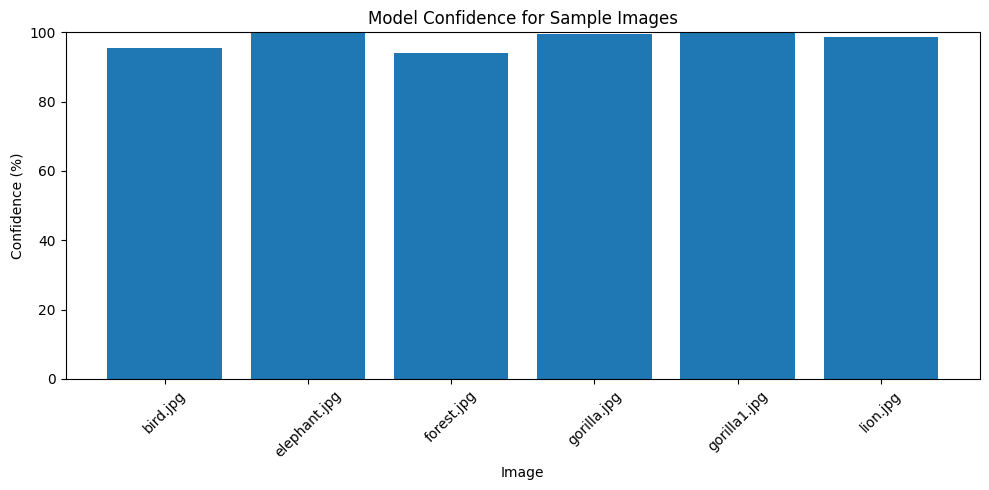

In [78]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Image"],
    results_df["Confidence (%)"]
)

plt.title("Model Confidence for Sample Images")
plt.xlabel("Image")
plt.ylabel("Confidence (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [79]:
class_summary = results_df.groupby("Actual Class").agg(
    Images=("Image", "count"),
    Average_Confidence=("Confidence (%)", "mean")
).reset_index()

class_summary["Average_Confidence"] = (
    class_summary["Average_Confidence"].round(2)
)

class_summary

,Actual Class,Images,Average_Confidence
0,bird,1,95.45
1,elephant,1,99.98
2,forest,1,93.94
3,giraffe,2,99.70
4,lion,1,98.78


In [80]:
def classify_image(image_path):
    pred_class, pred_idx, probabilities = learn.predict(image_path)

    confidence = probabilities[pred_idx].item() * 100

    print("\n" + "=" * 55)
    print("        FIVE-CLASS IMAGE CLASSIFIER")
    print("=" * 55)
    print(f"Image       : {image_path}")
    print(f"Prediction  : {pred_class}")
    print(f"Confidence  : {confidence:.2f}%")
    print("=" * 55)

    return str(pred_class), confidence

In [81]:
classify_image(
    r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg"
)


        FIVE-CLASS IMAGE CLASSIFIER
Image       : C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg
Prediction  : lion
Confidence  : 98.78%


('lion', 98.77811670303345)

In [82]:
def show_probabilities(image_path):

    pred_class, pred_idx, probabilities = learn.predict(image_path)

    probability_data = pd.DataFrame({
        "Class": learn.dls.vocab,
        "Probability (%)": [
            round(p.item() * 100, 2)
            for p in probabilities
        ]
    })

    probability_data = probability_data.sort_values(
        "Probability (%)",
        ascending=False
    )

    print(f"Prediction: {pred_class}")
    print()
    display(probability_data)

    plt.figure(figsize=(9, 5))

    plt.bar(
        probability_data["Class"],
        probability_data["Probability (%)"]
    )

    plt.title("Prediction Probability by Class")
    plt.xlabel("Class")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

Prediction: lion



,Class,Probability (%)
4,lion,98.78
1,elephant,1.18
0,bird,0.02
2,forest,0.02
3,giraffe,0.01


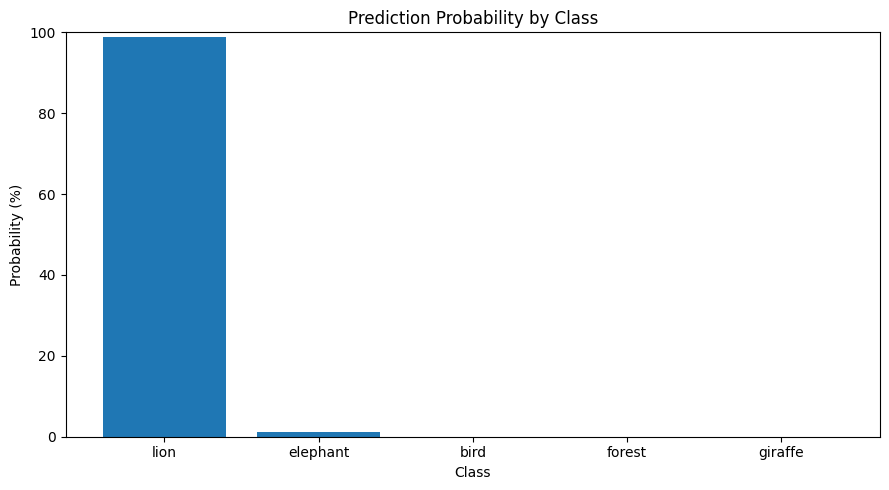

In [83]:
show_probabilities(
    r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg"
)

In [84]:
learn.export("five_class_animal_classifier.pkl")

print("Model saved successfully!")

Model saved successfully!


In [85]:
learn_loaded = load_learner(
    "five_class_animal_classifier.pkl"
)

print("Saved model loaded successfully!")
print("Classes:", learn_loaded.dls.vocab)

Saved model loaded successfully!
Classes: ['bird', 'elephant', 'forest', 'giraffe', 'lion']


C:\Users\educa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fastai\learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [87]:
pred_class, pred_idx, probabilities = learn_loaded.predict(
    r"C:\Users\educa\Downloads\is_it_a_bird_5_classes\lion\lion.jpg"
)

confidence = probabilities[pred_idx].item() * 100

print("Prediction:", pred_class)
print(f"Confidence: {confidence:.2f}%")

Prediction: lion
Confidence: 98.78%


# Final Project Summary

## Improved Image Classification System

The original image classification project was extended from a simple bird-versus-forest classification task into a five-class image classification system.

The final classes are:

1. Bird
2. Elephant
3. Forest
4. Giraffe
5. Lion

A pretrained ResNet18 architecture was used through transfer learning with the fastai library.

The model was trained using image resizing and data augmentation. A reusable prediction function was also developed to classify new images and display the predicted class and confidence.

The project demonstrates how transfer learning can be adapted to a multi-class image classification problem.

## Important Dataset Limitation

The current demonstration dataset contains only a very small number of images. Therefore, the prediction results demonstrate the workflow rather than providing a reliable measurement of real-world classification performance.

A larger dataset containing many different images for each class would be required for a robust evaluation.

# Conclusion

This project successfully extends the original "Is It a Bird?" image classifier into a five-class image classification system.

The system can distinguish between:

- Bird
- Elephant
- Forest
- Giraffe
- Lion

Transfer learning with ResNet18 provides a practical approach because the pretrained network already contains useful visual features.

The project also includes image prediction, confidence estimation, probability visualization, result tables, and model exporting.

The main limitation is the size of the current dataset. Future improvement should focus on collecting more images for every class and creating separate training, validation, and test datasets. This would allow the model's generalization performance to be evaluated properly.

Overall, the project demonstrates the complete workflow of preparing image data, creating a deep-learning model, training it, testing predictions, analyzing results, and saving the trained classifier.

# 🦁 Is It a Bird? — Multi-Class Image Classification

### Deep Learning Image Recognition Project

**Classes:** Bird • Elephant • Forest • Giraffe • Lion

**Architecture:** ResNet18  
**Framework:** fastai / PyTorch  
**Learning Approach:** Transfer Learning

---

### Project Objective

The objective of this project is to extend a basic bird-versus-forest image classifier into a multi-class image recognition system capable of identifying five different categories.